# Rescue Bot Training Notebook
This notebook trains and evaluates a policy-gradient agent for the Rescue Bot environment.

In [1]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import clear_output


from rescue_bot.env import RescueBotEnv
from rescue_bot.policy import PolicyNet, reinforce_update

## 1) Imports and Setup
Load the libraries used for training, plotting, and environment/policy definitions.

In [ ]:
def train_agent(env, num_episodes=5000, gamma=0.99, lr=3e-4):
    # =====================================================================
    # STEP 1: INITIALIZATION
    # Create the policy network and the optimizer that updates
    # model weights to improve performance (Adam here).
    # =====================================================================
    policy = PolicyNet(obs_size=env.obs_size, n_actions=env.n_actions)
    optimizer = optim.Adam(policy.parameters(), lr=lr)
    
    # History for plots
    history = {
        "rewards": [],
        "rescued": [],
        "steps": [],
        "losses": []
    }
    
    # Outer loop: play full episodes.
    for episode in range(num_episodes):
        obs = env.reset()
        
        # Episode memory: REINFORCE needs the full trajectory
        # before it can learn, so we store actions and rewards.
        log_probs = []
        rewards = []
        entropies = []
        done = False
        
        # =====================================================================
        # STEP 2: TRAJECTORY COLLECTION (play one episode)
        # =====================================================================
        while not done:
            # Prepare data for PyTorch
            obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
            action_mask = torch.tensor(env.get_action_mask(), dtype=torch.bool).unsqueeze(0)
            
            # A) Inference (forward pass)
            # The network analyzes the state and outputs action probabilities
            # for each possible action (for example: 70% Up, 10% Down, etc.).
            dist = policy(obs_tensor, action_mask)
            
            # B) Sampling (exploration)
            # Sample an action according to those probabilities.
            action = dist.sample()
            
            # C) Save action probability
            # Store the log-probability of the chosen action.
            # This is what will be differentiated during optimization.
            log_probs.append(dist.log_prob(action))
            entropies.append(dist.entropy())
            
            # D) Environment interaction
            # The agent acts, then the environment returns next state and reward.
            obs, reward, done, info = env.step(action.item())
            rewards.append(reward)  # Store the immediate reward
            
        # =====================================================================
        # STEP 3: LEARNING (weight update)
        # Episode is over; update the policy based on its trajectory.
        # =====================================================================
        # This function will:
        # 1. Compute discounted returns (G_t) backward through time.
        # 2. Compute the loss: - sum(log_prob * G_t)
        # 3. Run backpropagation (loss.backward()) and optimizer.step()
        loss = reinforce_update(policy, optimizer, log_probs, rewards, entropies, gamma)
        
        # =====================================================================
        # STEP 4: LOGGING AND MONITORING
        # =====================================================================
        history["rewards"].append(sum(rewards))
        history["rescued"].append(env.rescued)
        history["steps"].append(env.steps)
        history["losses"].append(loss)
        
        if (episode + 1) % 100 == 0:
            print(f"Episode {episode+1}/{num_episodes} | Mean reward (last 100): {np.mean(history['rewards'][-100:]):.1f} | Max evacuated: {np.max(history['rescued'][-100:])}")
            
    return policy, history

# Run training
env = RescueBotEnv()
trained_policy, training_history = train_agent(env, num_episodes=5000, gamma=0.99, lr=3e-4)

Episode 100/5000 | Moyenne Reward (100 derniers): -268.4 | Evacués max: 3
Episode 200/5000 | Moyenne Reward (100 derniers): -250.6 | Evacués max: 2
Episode 300/5000 | Moyenne Reward (100 derniers): -243.4 | Evacués max: 3
Episode 400/5000 | Moyenne Reward (100 derniers): -238.9 | Evacués max: 2
Episode 500/5000 | Moyenne Reward (100 derniers): -245.5 | Evacués max: 3
Episode 600/5000 | Moyenne Reward (100 derniers): -234.0 | Evacués max: 2
Episode 700/5000 | Moyenne Reward (100 derniers): -236.3 | Evacués max: 3
Episode 800/5000 | Moyenne Reward (100 derniers): -229.1 | Evacués max: 3
Episode 900/5000 | Moyenne Reward (100 derniers): -235.0 | Evacués max: 2
Episode 1000/5000 | Moyenne Reward (100 derniers): -231.8 | Evacués max: 3
Episode 1100/5000 | Moyenne Reward (100 derniers): -226.6 | Evacués max: 4
Episode 1200/5000 | Moyenne Reward (100 derniers): -238.8 | Evacués max: 4
Episode 1300/5000 | Moyenne Reward (100 derniers): -227.4 | Evacués max: 2
Episode 1400/5000 | Moyenne Reward

## 2) Training Loop
Define and run REINFORCE training with action masking, then collect training history.

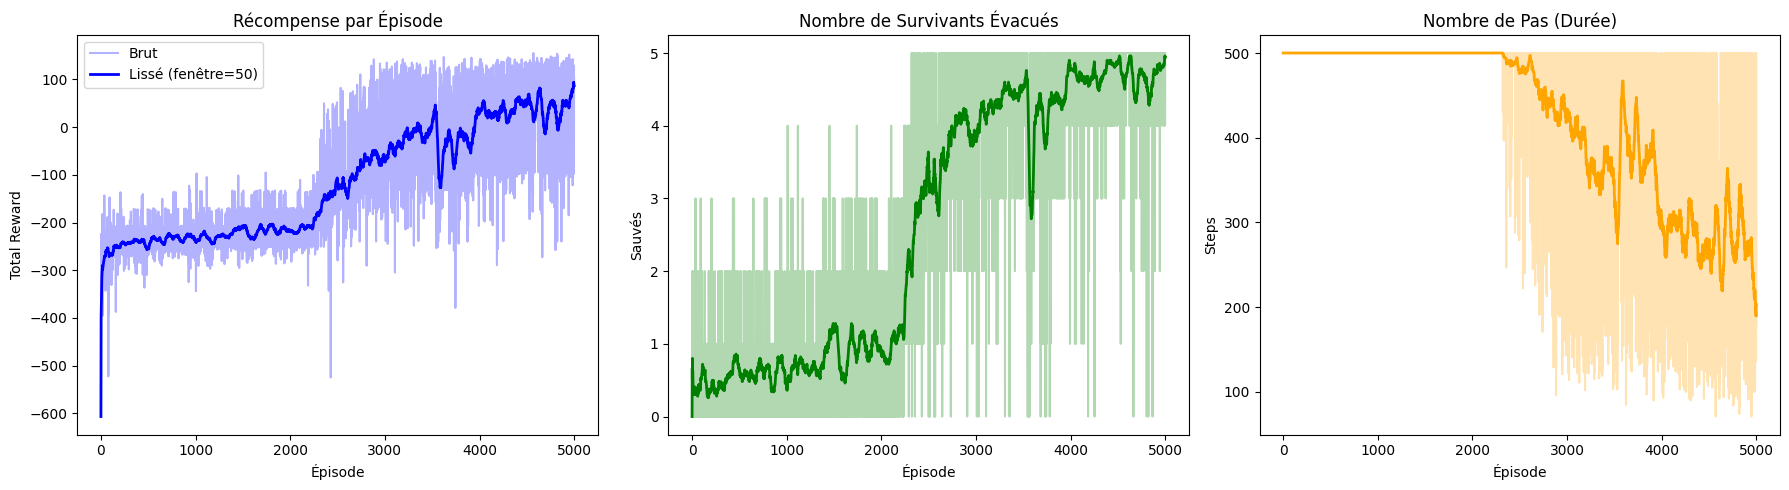

In [ ]:
def plot_training(history, window=50):
    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    # Smoothing with Pandas
    df = pd.DataFrame(history)
    smoothed = df.rolling(window, min_periods=1).mean()
    
    # Curve 1: Rewards
    axs[0].plot(df["rewards"], alpha=0.3, color='blue', label='Raw')
    axs[0].plot(smoothed["rewards"], color='blue', linewidth=2, label=f'Smoothed (window={window})')
    axs[0].set_title("Reward per Episode")
    axs[0].set_xlabel("Episode")
    axs[0].set_ylabel("Total Reward")
    axs[0].legend()
    
    # Curve 2: Number rescued
    axs[1].plot(df["rescued"], alpha=0.3, color='green')
    axs[1].plot(smoothed["rescued"], color='green', linewidth=2)
    axs[1].set_title("Evacuated Survivors")
    axs[1].set_xlabel("Episode")
    axs[1].set_ylabel("Rescued")
    
    # Curve 3: Episode length
    axs[2].plot(df["steps"], alpha=0.3, color='orange')
    axs[2].plot(smoothed["steps"], color='orange', linewidth=2)
    axs[2].set_title("Number of Steps (Duration)")
    axs[2].set_xlabel("Episode")
    axs[2].set_ylabel("Steps")
    
    plt.tight_layout()
    plt.show()

plot_training(training_history)

## 3) Training Metrics Visualization
Plot rewards, rescued survivors, and episode length with rolling smoothing.

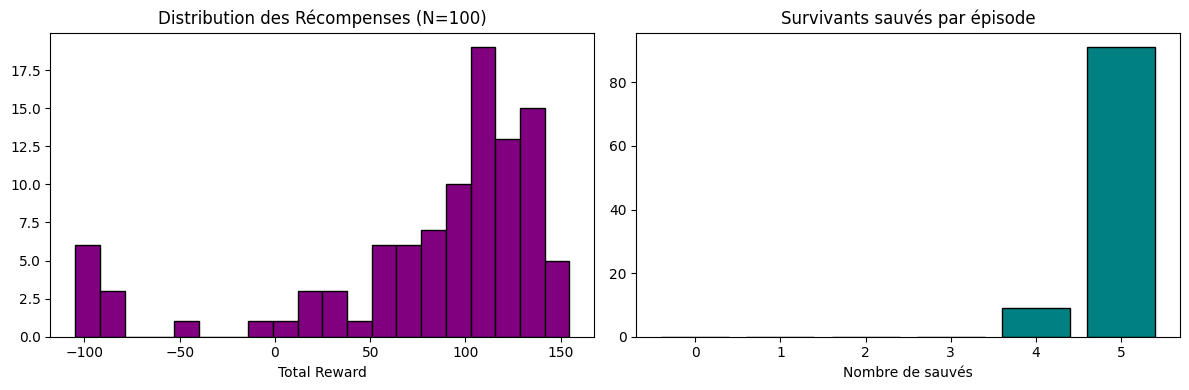

Moyenne de récompense : 79.7 ± 66.5
Taux de succès total (5/5) : 91.0%


In [ ]:
def evaluate_agent(env, policy, num_eval_episodes=100):
    eval_rewards = []
    eval_rescued = []
    
    with torch.no_grad():  # No gradient computation during evaluation
        for _ in range(num_eval_episodes):
            obs = env.reset()
            done = False
            ep_reward = 0
            
            while not done:
                obs_tensor = torch.tensor(obs, dtype=torch.float32).unsqueeze(0)
                action_mask = torch.tensor(env.get_action_mask(), dtype=torch.bool).unsqueeze(0)
                
                # During evaluation, you can choose argmax action
                # instead of sampling to reduce variance
                dist = policy(obs_tensor, action_mask)
                # action = torch.argmax(dist.probs)
                action = dist.sample()

                obs, reward, done, _ = env.step(action.item())
                ep_reward += reward
                
            eval_rewards.append(ep_reward)
            eval_rescued.append(env.rescued)
            
    # Plot evaluation results
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    
    axs[0].hist(eval_rewards, bins=20, color='purple', edgecolor='black')
    axs[0].set_title(f"Reward Distribution (N={num_eval_episodes})")
    axs[0].set_xlabel("Total Reward")
    
    # Discrete histogram for rescued survivors (0 to 5)
    bins = np.arange(env.NUM_SURVIVORS + 2) - 0.5
    axs[1].hist(eval_rescued, bins=bins, color='teal', edgecolor='black', rwidth=0.8)
    axs[1].set_title("Rescued Survivors per Episode")
    axs[1].set_xlabel("Number Rescued")
    axs[1].set_xticks(range(env.NUM_SURVIVORS + 1))
    
    plt.tight_layout()
    plt.show()
    
    print(f"Average reward: {np.mean(eval_rewards):.1f} +- {np.std(eval_rewards):.1f}")
    print(f"Full success rate ({env.NUM_SURVIVORS}/{env.NUM_SURVIVORS}): {np.mean(np.array(eval_rescued) == env.NUM_SURVIVORS) * 100:.1f}%")

evaluate_agent(env, trained_policy)

## 4) Policy Evaluation
Run evaluation episodes and visualize reward and rescue distributions.

In [5]:
torch.save(trained_policy.state_dict(), "rescue_bot_policy.pth")
print("Model saved as 'rescue_bot_policy.pth")

Model saved as 'rescue_bot_policy.pth


## 5) Save Trained Model
Persist the trained policy weights to disk for later inference or testing.